In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

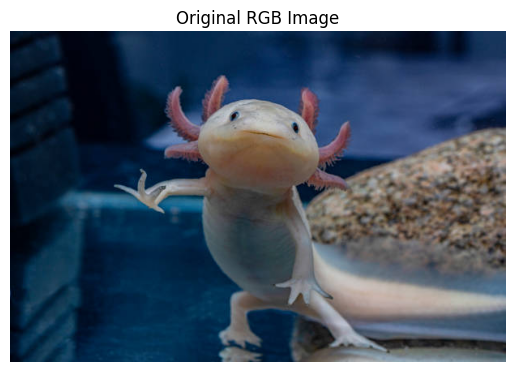

In [2]:
image_path = '../../input.jpg'
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title('Original RGB Image')
plt.axis('off')
plt.show()

In [3]:
def rgb_to_hsi(image):
    image = image.astype(np.float64) / 255.0
    r, g, b = image[:, :, 0], image[:, :, 1], image[:, :, 2]

    intensity = (r + g + b) / 3.0

    min_rgb = np.minimum(np.minimum(r, g), b)
    saturation = np.where(intensity != 0, 1 - min_rgb / intensity, 0)

    numerator = 0.5 * ((r - g) + (r - b))
    denominator = np.sqrt((r - g) ** 2 + (r - b) * (g - b))

    hue = np.arccos(np.clip(numerator / (denominator + 1e-6), -1, 1))
    hue = np.where(b <= g, hue, 2 * np.pi - hue)
    hue = hue / (2 * np.pi)

    return hue, saturation, intensity

hue, saturation, intensity = rgb_to_hsi(image_rgb)

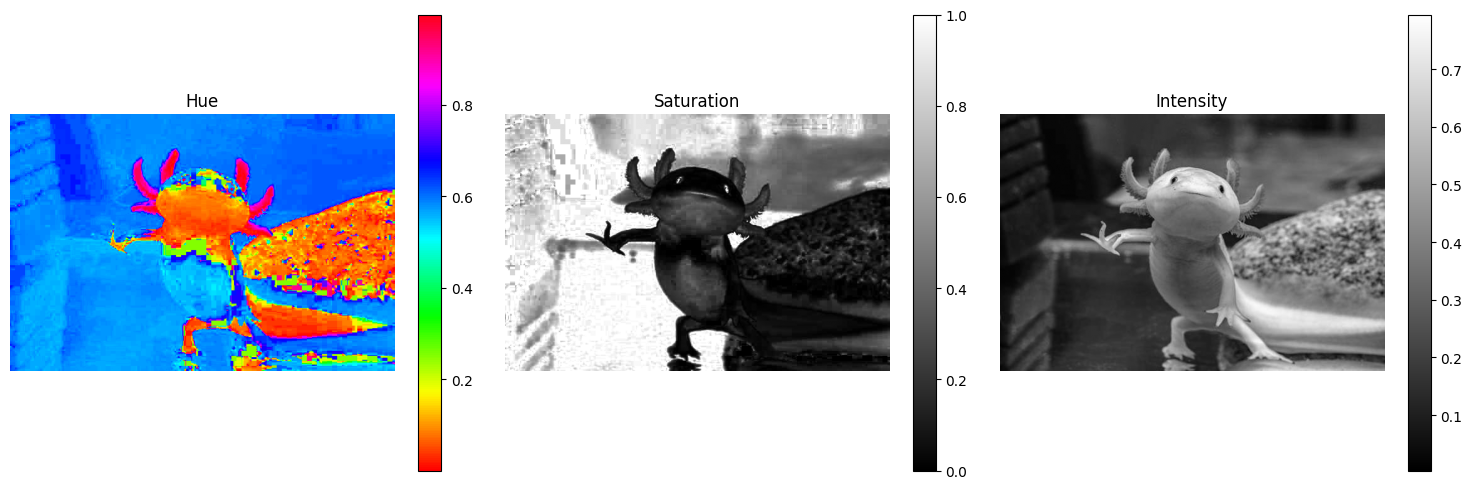

In [4]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(hue, cmap='hsv')
plt.title('Hue')
plt.colorbar()
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(saturation, cmap='gray')
plt.title('Saturation')
plt.colorbar()
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(intensity, cmap='gray')
plt.title('Intensity')
plt.colorbar()
plt.axis('off')

plt.tight_layout()
plt.show()